## 1g-1g mergers

In [1]:
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")  # silence LAL warnings

# general modules
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt
plt.rc('figure', figsize=(8, 5))
plt.rcParams.update({'text.usetex': True,'text.latex.preamble':r'\usepackage{amsmath}',
                     'font.family': 'serif','font.serif': ['Georgia'],'mathtext.fontset': 'cm',
                     'lines.linewidth': 1.8,'font.size': 18,'xtick.labelsize': 'large',
                     'ytick.labelsize': 'large','xtick.direction': 'in','ytick.direction': 'in',
                     'xtick.major.width': 1.4,'ytick.major.width': 1.4,'xtick.major.size': 5.,
                     'ytick.major.size': 5.,'ytick.right':True,'axes.labelsize': 'large',
                     'axes.titlesize': 'large','axes.grid': True,'grid.alpha': 0.5,
                     'lines.markersize': 12,'legend.borderpad': 0.2,'legend.fancybox': True,
                     'legend.fontsize': 15,'legend.framealpha': 0.7,'legend.handletextpad': 0.5,
                     'legend.labelspacing': 0.2,'legend.loc': 'best','savefig.bbox': 'tight',
                     'savefig.pad_inches': 0.05,'savefig.dpi': 80,'pdf.compression': 9})

import sys
sys.path.append("/Users/tousifislam/Research/projects/astro_projects/prec_hierarchical/gwGenealogy/")
import gwGenealogy

# import rit kick module
from gwGenealogy.remnants import bbh_final_state_precessing_NRSur7dq4Remnant
from gwGenealogy.remnants import bbh_final_kick_precessing_CLZM2007

Loaded NRSur7dq4Remnant fit.
Loaded NRSur3dq8Remnant fit.


In [2]:
# 1g : mass distribtuion
m1 = gwGenealogy.core.sample_powerlaw_1d(n_samples=1000, beta=-1.3, xmin=5, xmax=50, seed=40)
m2 = gwGenealogy.core.sample_powerlaw_1d(n_samples=1000, beta=-1.3, xmin=5, xmax=50, seed=50)
# 1g : spin distribution
s1_vec, s2_vec = gwGenealogy.core.sample_isotropic_spins(n_samples=1000, chi_min=0, chi_max=1)
# 1g + 1g : final properties from surrogate
mf, chif, vf = bbh_final_state_precessing_NRSur7dq4Remnant(m1, m2, s1_vec, s2_vec)

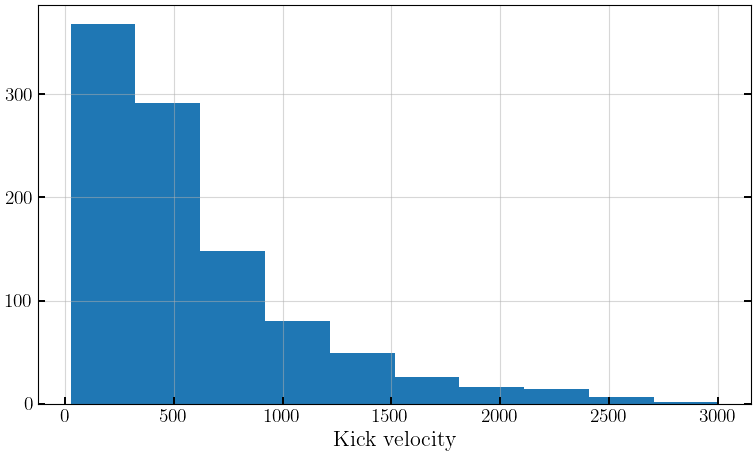

In [3]:
plt.hist(vf);
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Kick velocity', fontsize=16)
plt.tight_layout()
plt.show()

In [4]:
# Sample globular cluster escape velocityies : actual data
vesc_gc = gwGenealogy.vescape.sample_globular_cluster_vesc_distribution(n_samples=5000)
# Sample globular cluster escape velocityies : uniform distribution
vesc_gc_uni = gwGenealogy.vescape.sample_uniform_globular_cluster_vesc_distribution(n_samples=5000)
# Sample globular cluster escape velocityies : gaussian distribution
vesc_gc_gauss = gwGenealogy.vescape.sample_gaussian_globular_cluster_vesc_distribution(n_samples=5000)

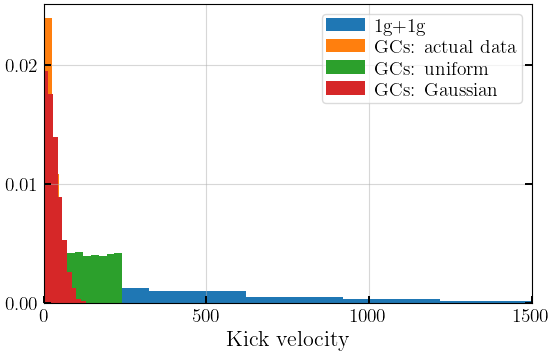

In [5]:
plt.figure(figsize=(6,4))
plt.hist(vf, density=True, label='1g+1g');
plt.hist(vesc_gc, density=True, label='GCs: actual data');
plt.hist(vesc_gc_uni, density=True, label='GCs: uniform');
plt.hist(vesc_gc_gauss, density=True, label='GCs: Gaussian');
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Kick velocity', fontsize=16)
plt.xlim(0,1500)
plt.tight_layout()
plt.legend(fontsize=14)
plt.show()

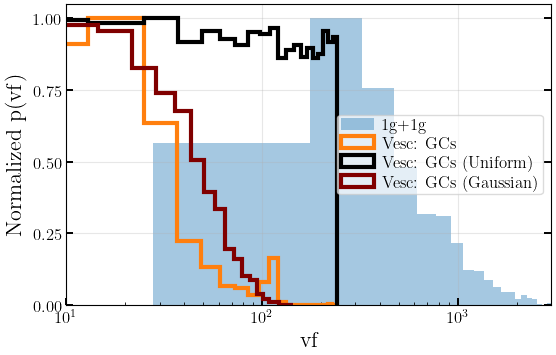

In [6]:
plt.figure(figsize=(6,4))

# Normalize each dataset so its histogram peak will be 1
plt.hist(vf, bins=20, histtype='stepfilled', alpha=0.4,
         label='1g+1g', edgecolor='none', density=False, 
         weights=np.ones(len(vf))/np.max(np.histogram(vf, bins=20)[0]))
plt.hist(vesc_gc, bins=20, histtype='step', alpha=1, lw=3,
         label='Vesc: GCs', edgecolor='C1', density=False, 
         weights=np.ones(len(vesc_gc))/np.max(np.histogram(vesc_gc, bins=20)[0]))
plt.hist(vesc_gc_uni, bins=20, histtype='step', alpha=1, 
         label='Vesc: GCs (Uniform)', edgecolor='k', lw=3, density=False, 
         weights=np.ones(len(vesc_gc_uni))/np.max(np.histogram(vesc_gc_uni, bins=20)[0]))
plt.hist(vesc_gc_gauss, bins=20, histtype='step', alpha=1, 
         label='Vesc: GCs (Gaussian)', edgecolor='maroon', lw=3, density=False, 
         weights=np.ones(len(vesc_gc_gauss))/np.max(np.histogram(vesc_gc_gauss, bins=20)[0]))


# Set log scales
plt.xscale('log')
#plt.yscale('log')
plt.xlim(10,3000)
plt.xlabel('vf', fontsize=16)
plt.ylabel('Normalized p(vf)', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
# 1g + 1g : final properties from surrogate
# s1_vec_nospin = []
# s2_vec_nospin = []
# for i in range(len(m1)):
#     s1_vec_nospin.append([0,0,0])
#     s2_vec_nospin.append([0,0,0])
# mf_nospin, chif_nospin, vf_nospin = bbh_final_state_precessing_NRSur7dq4(m1, m2, s1_vec_nospin, s2_vec_nospin)
mf_nospin, chif_nospin, vf_nospin = bbh_final_state_precessing_NRSur7dq4Remnant(m1, m2, s1_vec, s2_vec, bbh='nonspinning')

In [8]:
# 1g + 1g : final properties from surrogate
# s1_vec_as = []
# s2_vec_as = []
# for i in range(len(m1)):
#     s1_vec_as.append([0,0,np.linalg.norm(s1_vec[i])])
#     s2_vec_as.append([0,0,np.linalg.norm(s2_vec[i])])
# mf_as, chif_as, vf_as = bbh_final_state_precessing_NRSur7dq4(m1, m2, s1_vec_as, s2_vec_as)
mf_as, chif_as, vf_as = bbh_final_state_precessing_NRSur7dq4Remnant(m1, m2, s1_vec, s2_vec, bbh='aligned_spin_projected')

In [9]:
# 1g + 1g : final properties from surrogate
# s1_vec_az = []
# s2_vec_az = []
# for i in range(len(m1)):
#     s1_vec_az.append([0,0,s1_vec[i][-1]])
#     s2_vec_az.append([0,0,s2_vec[i][-1]])
# mf_az, chif_az, vf_az = bbh_final_state_precessing_NRSur7dq4(m1, m2, s1_vec_az, s2_vec_az)
mf_az, chif_az, vf_az = bbh_final_state_precessing_NRSur7dq4Remnant(m1, m2, s1_vec, s2_vec, bbh='aligned_spin')

In [10]:
# 1g + 1g : final properties from surrogate
# s1_vec_1prec = []
# s2_vec_1prec = []
# for i in range(len(m1)):
#     s1_vec_1prec.append([s1_vec[i][0],s1_vec[i][1],s1_vec[i][2]])
#     s2_vec_1prec.append([0,0,0])
# mf_1prec, chif_1prec, vf_1prec = bbh_final_state_precessing_NRSur7dq4(m1, m2, s1_vec_1prec, s2_vec_1prec)
mf_1prec, chif_1prec, vf_1prec = bbh_final_state_precessing_NRSur7dq4Remnant(m1, m2, s1_vec, s2_vec, bbh='single_spin_precession')

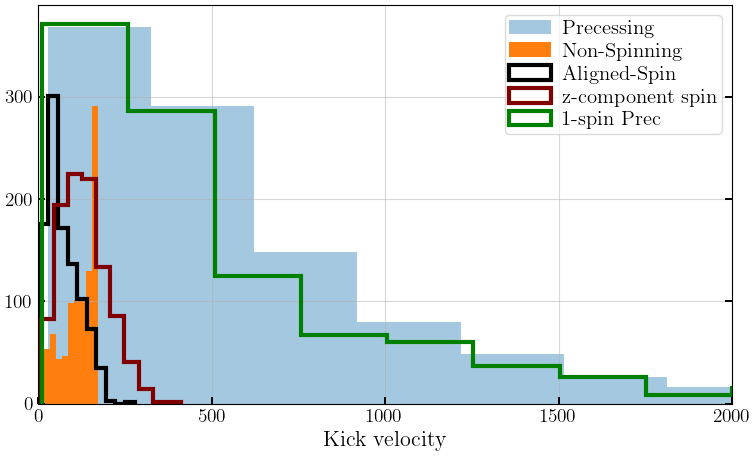

In [11]:
plt.hist(vf, alpha=0.4, label='Precessing');
plt.hist(vf_nospin, label='Non-Spinning');
plt.hist(vf_as, lw=3, histtype='step', color='k', label='Aligned-Spin');
plt.hist(vf_az, lw=3, histtype='step', color='maroon', label='z-component spin');
plt.hist(vf_1prec, lw=3, histtype='step', color='g', label='1-spin Prec');
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Kick velocity', fontsize=16)
#plt.xscale('log')
plt.xlim(xmin=0,xmax=2000)
plt.legend()
plt.tight_layout()
plt.show()